In [9]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img = cv.imread('./sample.jpg', cv.IMREAD_GRAYSCALE)

t, bin_img = cv.threshold(img[:,:,2], 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)
plt.imshow(bin_img, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

b = bin_img[bin_img.shape[0]//2 :   bin_img.shape[0], 0:bin_img.shape[0]//2+1]
plt.imshow(b, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

se = np.uint8([[0,0,1,0,0],
               [0,1,1,1,0],
               [1,1,1,1,1]
               [0,1,1,1,0],
               [0,0,1,0,0]])

b_dilation = cv.dilate(b, se, iterations=1)
plt.imshow(b_dilation, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

b_erosion = cv.erode(b, se, iterations=1)
plt.imshow(b_erosion, cmap='gray'), plt.xticks([]), plt.yticks([])

b_closing = cv.erode(cv.dilate(b, se, iterations=1), se, iterations=1)
plt.imshow(b_closing, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

<>:17: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?
<>:17: SyntaxWarning: list indices must be integers or slices, not tuple; perhaps you missed a comma?


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

In [4]:
img = cv.imread('./dino.jpg')
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25)

def gamma(f, gamma=1.0):
    f1 = f / 255.0
    return np.uint8(255 * (f1 ** gamma))

gc = np.hstack([gamma(img, 0.5), gamma(img, 0.75), gamma(img, 1.0), gamma(img, 2.0), gamma(img, 3.0)])

cv.imshow('gamma', gc)

cv.waitKey()
cv.destroyAllWindows()

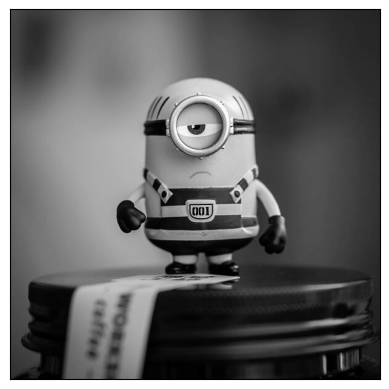

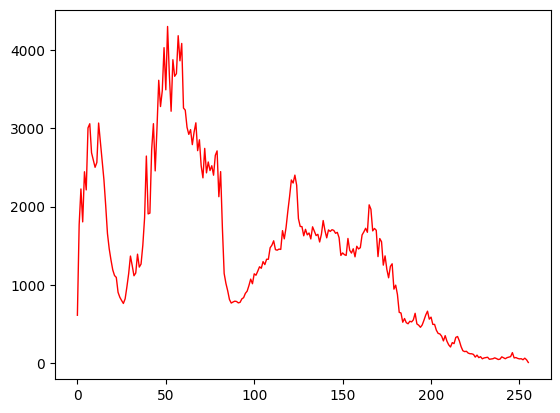

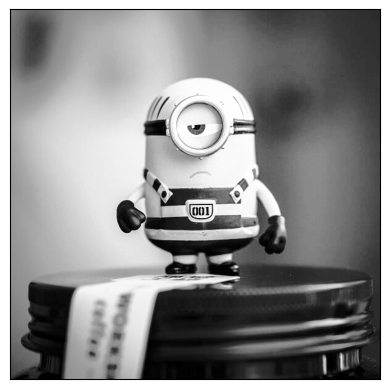

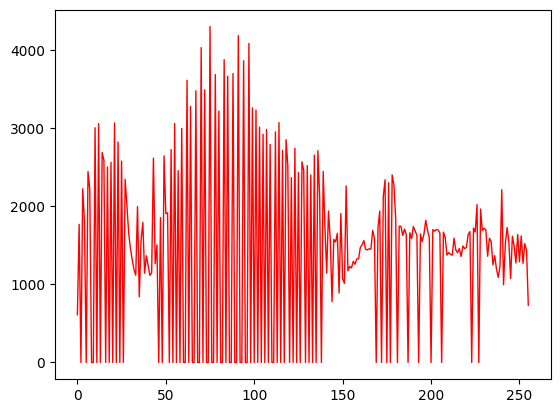

In [8]:
img = cv.imread('./sample.jpg')

gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

h = cv.calcHist([gray], [0], None, [256], [0,256])
plt.plot(h, color='r', linewidth=1)
plt.show()

equal = cv.equalizeHist(gray)
plt.imshow(equal, cmap='gray'), plt.xticks([]), plt.yticks([])
plt.show()

h = cv.calcHist([equal], [0], None, [256], [0,256])
plt.plot(h, color='r', linewidth=1)
plt.show()

In [2]:
import cv2 as cv

img = cv.imread('./sample.jpg')
patch = img[250:350, 170:270, :]

img = cv.rectangle(img, (170,250), (270,350), (0,255,0), 2)

patch1 = cv.resize(patch, dsize=(0,0), fx=5, fy=5, interpolation=cv.INTER_NEAREST)
patch2 = cv.resize(patch, dsize=(0,0), fx=5, fy=5, interpolation=cv.INTER_LINEAR)
patch3 = cv.resize(patch, dsize=(0,0), fx=5, fy=5, interpolation=cv.INTER_CUBIC)

cv.imshow('img', img)
cv.imshow('patch1', patch1)
cv.imshow('patch2', patch2)
cv.imshow('patch3', patch3)

cv.waitKey()
cv.destroyAllWindows()